In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import numpy as np
import znnl as nl

import pandas as pd

from flax import linen as nn
import optax

import matplotlib.pyplot as plt
from neural_tangents import stax

import h5py as hf

from rich.progress import track

import seaborn as sns

2023-08-10 14:25:00.595157: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-08-10 14:25:06.491512: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Using backend: cpu

Available hardware:

TFRT_CPU_0

## Download the data

In [3]:
class AbaloneData(nl.data.DataGenerator):
    """
    Generator for the Abalone data-set.
    
    Notes
    -----
    
    URL: http://archive.ics.uci.edu/static/public/1/abalone.zip
    """
    
    def __init__(self, data_file: str = "abalone.data"):
        """
        Build the data-set.
        """
        self.data_file = data_file
        self.columns = [
            "Sex",
            "Length", 
            "Diameter", 
            "Height", 
            "Whole weight", 
            "Shucked weight", 
            "Viscera weight", 
            "Shell weight", 
            "Rings"
        ]
        
        # Collect the processed data
        processed_data = self._process_raw_data()
        
        # Create the data-sets
        train_ds = processed_data.sample(frac=0.8, random_state=0)
        train_labels = train_ds.pop("Rings")
        
        test_ds = processed_data.drop(train_ds.index)
        test_labels = test_ds.pop("Rings")
        
        self.train_ds = {
            "inputs": train_ds.to_numpy(), 
            "targets": train_labels.to_numpy().reshape(-1, 1)
        }
        self.test_ds = {
            "inputs": test_ds.to_numpy(), 
            "targets": test_labels.to_numpy().reshape(-1, 1)
        }
        
        self.data_pool = self.train_ds["inputs"]
        
        
    def _process_raw_data(self):
        """
        Process the raw data
        """
        # Process the raw data.
        raw_data = pd.read_csv(
            self.data_file, names=self.columns, na_values='?', comment='#',
                          sep=',', skipinitialspace=True
        )
        raw_data.dropna()
        
        # encode the sex data
        raw_data = pd.get_dummies(raw_data, columns=['Sex'], prefix='', prefix_sep='')
        # Normalize
        raw_data = (raw_data - raw_data.mean()) / raw_data.std()

        return raw_data
        
        

In [4]:
generator = AbaloneData()

## Experiment

In [5]:
ensembles = 20
optimizers = ["sgd", "traceopt", "adam"]

for i in range(ensembles):
    generator = AbaloneData()
    seed = np.random.randint(low=0, high=564864168)

    for opt in optimizers:
        network = stax.serial(
            stax.Dense(256),
            stax.Relu(),
            stax.Dense(256),
            stax.Relu(),
            stax.Dense(1),
        )
        
        if opt == "traceopt":
            optimizer = nl.optimizers.TraceOptimizer(
                scale_factor=1.0, subset=0.01, memory=100
            )
        elif opt == "adam":
            optimizer = optax.adam(1e-2)
        elif opt == "sgd":
            optimizer = optax.sgd(1.0)
        else:
            raise NotImplementedError(
                "Optimizer doesn't exist..."
            )

        model = nl.models.NTModel(
                nt_module=network,
                optimizer=optimizer,
                seed=seed,
                input_shape=(1, 10),
            )

        train_recorder = nl.training_recording.JaxRecorder(
            name=f"{opt}_train_recorder_{i}",
            loss=True,
            update_rate=1
        )
        test_recorder = nl.training_recording.JaxRecorder(
            name=f"{opt}_test_recorder_{i}",
            loss=True,
            update_rate=1
        )

        train_recorder.instantiate_recorder(
            data_set=generator.train_ds
        )
        test_recorder.instantiate_recorder(
            data_set=generator.test_ds
        )

        training_strategy = nl.training_strategies.SimpleTraining(
            model=model, 
            loss_fn=nl.loss_functions.MeanPowerLoss(order=2),
            recorders=[train_recorder, test_recorder],
        )
        _ = training_strategy.train_model(
                train_ds=generator.train_ds,
                test_ds=generator.test_ds, 
                epochs=50, 
                batch_size=256,
            )

        train_recorder.dump_records()
        test_recorder.dump_records()
    

Epoch: 49: 100%|█████████████████████████████████| 50/50 [00:10<00:00,  4.92batch/s, test_loss=0.51]


## Analysis

In [6]:
def load_data(file):
    with hf.File(file, "r") as db:
        data = db["loss"][:]
        
    return data

In [7]:
adam_data = []
adam_data_tr = []

for i in range(20):
    adam_data.append(
        load_data(f"adam_test_recorder_{i}.h5")
    )
    adam_data_tr.append(
        load_data(f"adam_train_recorder_{i}.h5")
    )

In [8]:
traceopt_data = []
traceopt_data_tr = []

for i in range(20):
    traceopt_data.append(
        load_data(f"traceopt_test_recorder_{i}.h5")
    )
    traceopt_data_tr.append(
        load_data(f"traceopt_train_recorder_{i}.h5")
    )

In [9]:
sgd_data = []
sgd_data_tr = []

for i in range(20):
    sgd_data.append(
        load_data(f"sgd_test_recorder_{i}.h5")
    )
    sgd_data_tr.append(
        load_data(f"sgd_train_recorder_{i}.h5")
    )

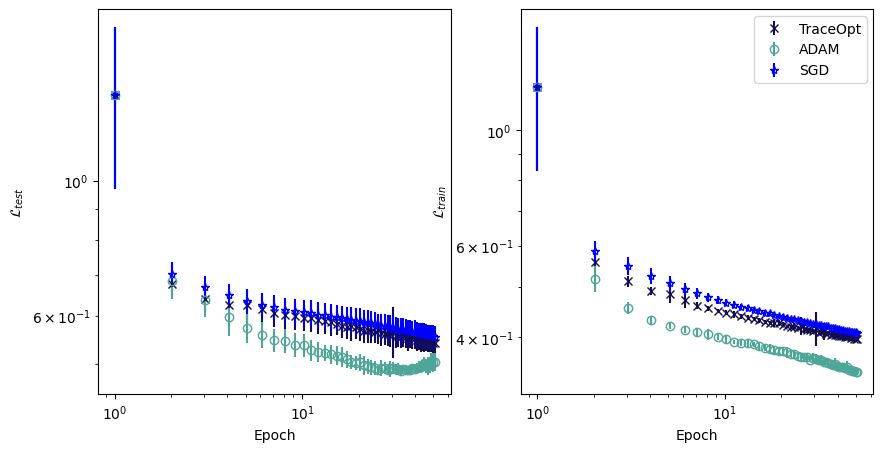

In [10]:
x = np.linspace(1, 51, 50)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].errorbar(
    x,
    np.mean(traceopt_data, axis=0), 
    yerr=np.std(traceopt_data, axis=0),
    marker='x',
    c = "#140D4F",
    mfc="none",
    linestyle="none",
    label="TraceOpt"
)
ax[0].errorbar(
    x,
    np.mean(adam_data, axis=0), 
    yerr=np.std(adam_data, axis=0),
    marker='o',
    c="#4EA699",
    mfc="none",
    linestyle="none",
    label="ADAM"
)
ax[0].errorbar(
    x,
    np.mean(sgd_data, axis=0), 
    yerr=np.std(sgd_data, axis=0),
    marker='*',
    c="blue",
    mfc="none",
    linestyle="none",
    label="SGD"
)

ax[1].errorbar(
    x,
    np.mean(traceopt_data_tr, axis=0), 
    yerr=np.std(traceopt_data_tr, axis=0),
    marker='x',
    c = "#140D4F",
    mfc="none",
    linestyle="none",
    label="TraceOpt"
)
ax[1].errorbar(
    x,
    np.mean(adam_data_tr, axis=0), 
    yerr=np.std(adam_data_tr, axis=0),
    marker='o',
    c="#4EA699",
    mfc="none",
    linestyle="none",
    label="ADAM"
)
ax[1].errorbar(
    x,
    np.mean(sgd_data_tr, axis=0), 
    yerr=np.std(sgd_data_tr, axis=0),
    marker='*',
    c="blue",
    mfc="none",
    linestyle="none",
    label="SGD"
)

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel(r"$\mathcal{L}_{test}$")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel(r"$\mathcal{L}_{train}$")

ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xscale("log")

plt.legend()
plt.savefig("abalone-vs-adam.pdf")
plt.show()